In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Python environment is ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Matplotlib is building the font cache; this may take a moment.


Python environment is ready!
Pandas: 3.0.6
NumPy: 2.4.6


In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1470
Columns: 35


In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Employee IDs:", df["EmployeeNumber"].duplicated().sum())

Duplicate rows: 0
Duplicate Employee IDs: 0


In [6]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [8]:
attrition_counts = df["Attrition"].value_counts()

print("Employees who stayed:", attrition_counts["No"])
print("Employees who left:", attrition_counts["Yes"])

print(
    "Attrition rate:",
    round((attrition_counts["Yes"] / len(df)) * 100, 2),
    "%"
)

Employees who stayed: 1233
Employees who left: 237
Attrition rate: 16.12 %


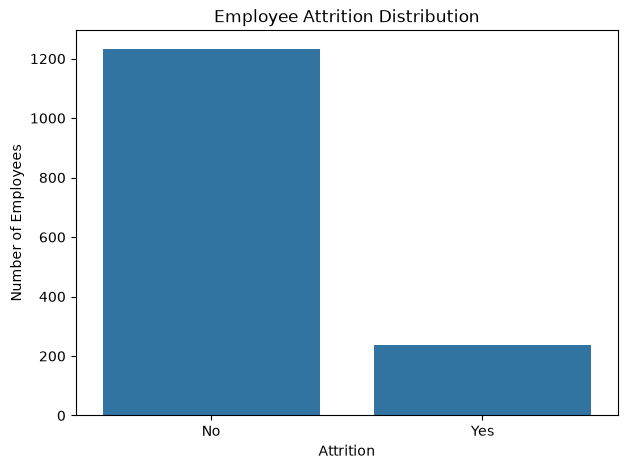

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

attrition_counts = df["Attrition"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=attrition_counts.index,
    y=attrition_counts.values
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

In [10]:
department_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

department_attrition

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


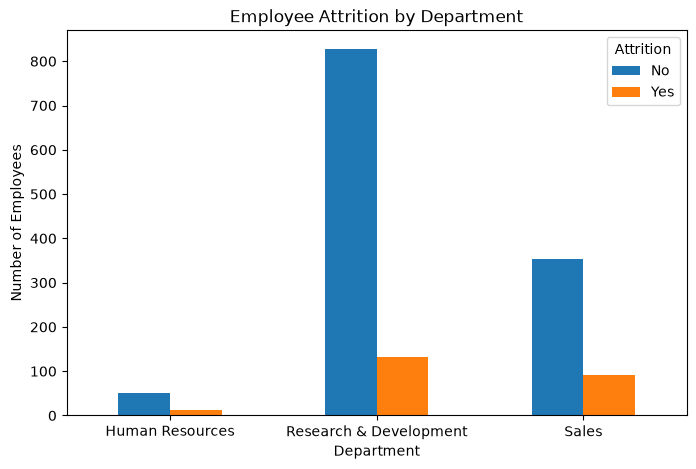

In [11]:
department_attrition.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Employee Attrition by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")

plt.show()

In [12]:
department_rate = (
    df.groupby("Department")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

department_rate

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

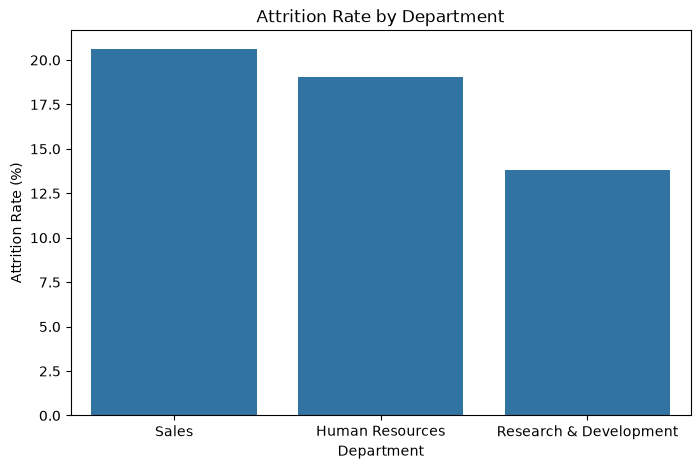

In [13]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=department_rate.index,
    y=department_rate.values
)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [14]:
job_role_rate = (
    df.groupby("JobRole")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

job_role_rate

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64

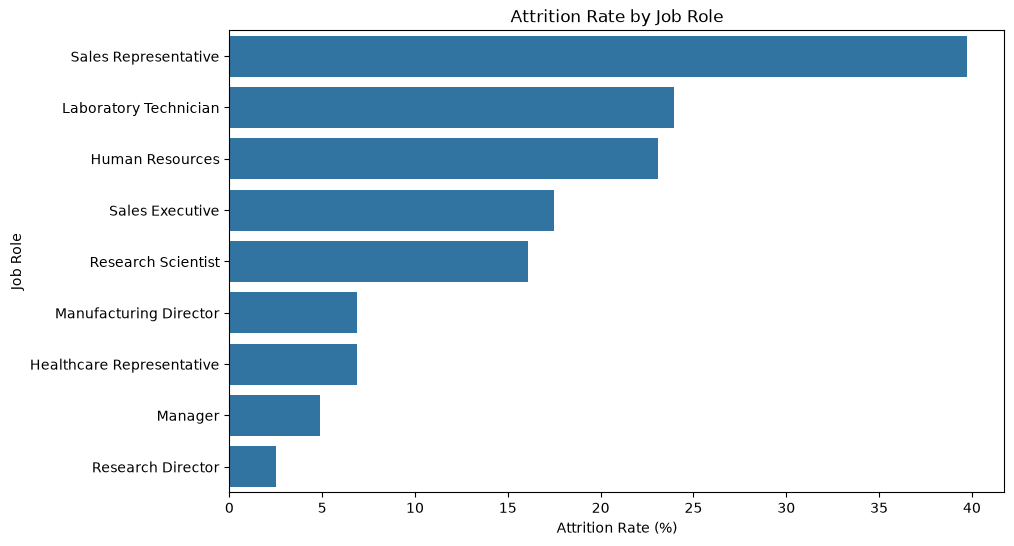

In [15]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=job_role_rate.values,
    y=job_role_rate.index
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

In [16]:
overtime_rate = (
    df.groupby("OverTime")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

overtime_rate

OverTime
Yes    30.53
No     10.44
Name: Attrition, dtype: float64

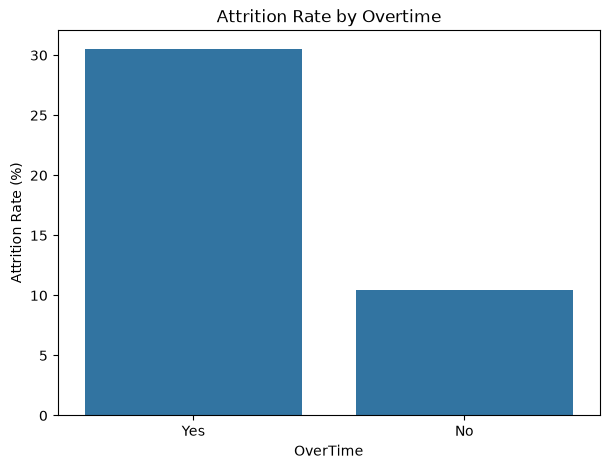

In [17]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=overtime_rate.index,
    y=overtime_rate.values
)

plt.title("Attrition Rate by Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [18]:
job_satisfaction_rate = (
    df.groupby("JobSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

job_satisfaction_rate

JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64

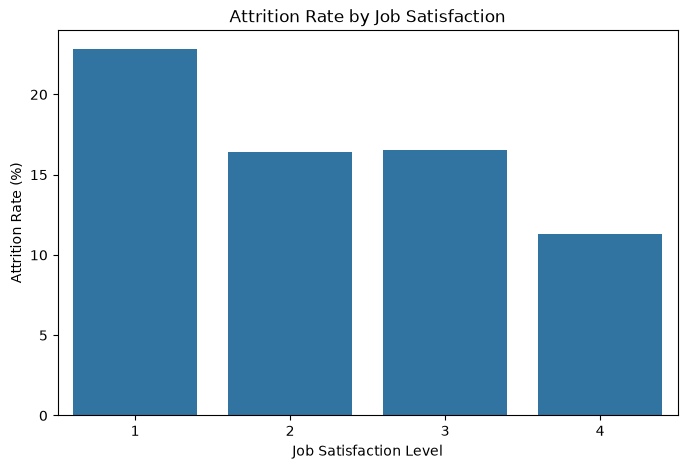

In [19]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=job_satisfaction_rate.index,
    y=job_satisfaction_rate.values
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [20]:
environment_satisfaction_rate = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

environment_satisfaction_rate

EnvironmentSatisfaction
1    25.35
2    14.98
3    13.69
4    13.45
Name: Attrition, dtype: float64

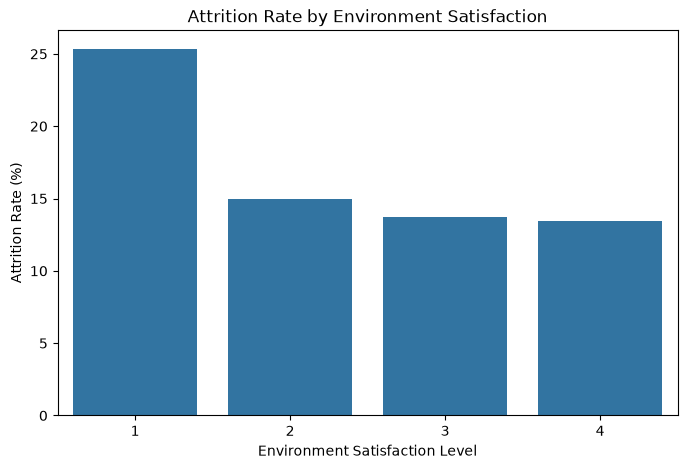

In [21]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=environment_satisfaction_rate.index,
    y=environment_satisfaction_rate.values
)

plt.title("Attrition Rate by Environment Satisfaction")
plt.xlabel("Environment Satisfaction Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

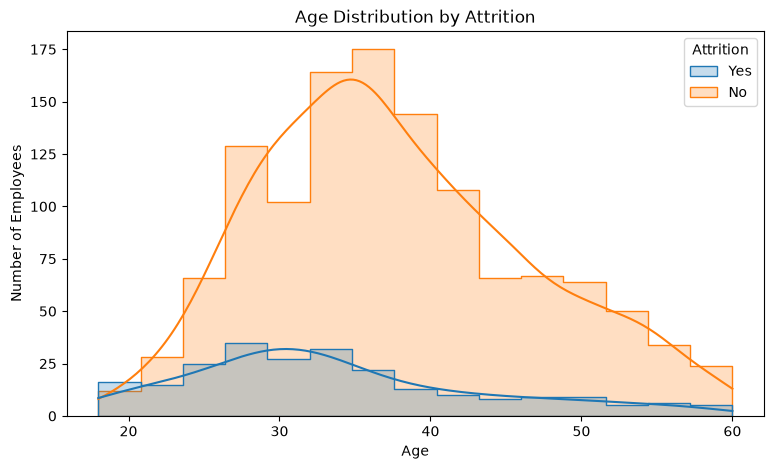

In [22]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Attrition",
    bins=15,
    kde=True,
    element="step"
)

plt.title("Age Distribution by Attrition")
plt.xlabel("Age")
plt.ylabel("Number of Employees")

plt.show()

In [23]:
age_summary = (
    df.groupby("Attrition")["Age"]
    .agg(["count", "mean", "median"])
    .round(2)
)

age_summary

,count,mean,median
Attrition,,,
No,1233,37.56,36.0
Yes,237,33.61,32.0


In [24]:
income_summary = (
    df.groupby("Attrition")["MonthlyIncome"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

income_summary

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.74,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


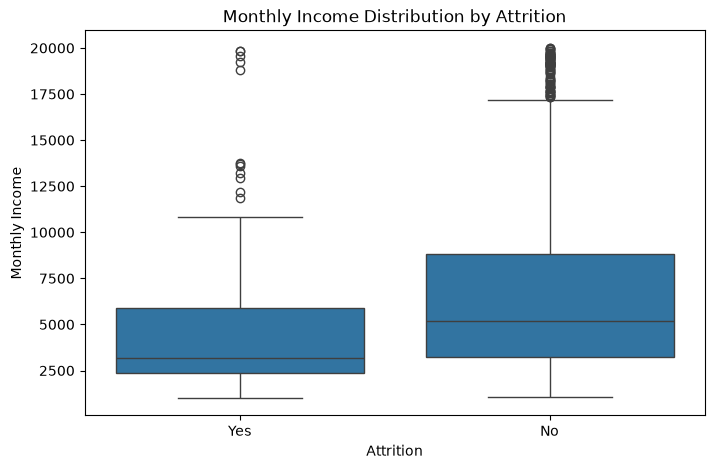

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome"
)

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

In [26]:
tenure_summary = (
    df.groupby("Attrition")["YearsAtCompany"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

tenure_summary

,count,mean,median,min,max
Attrition,,,,,
No,1233,7.37,6.0,0,37
Yes,237,5.13,3.0,0,40


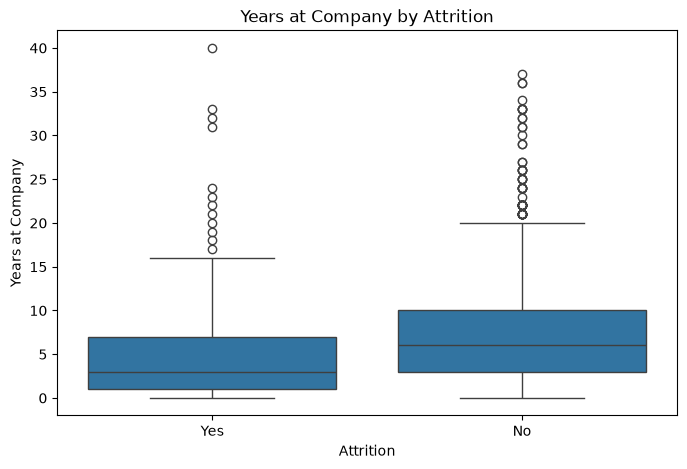

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany"
)

plt.title("Years at Company by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")

plt.show()

In [28]:
job_level_rate = (
    df.groupby("JobLevel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
)

job_level_rate

JobLevel
1    26.34
2     9.74
3    14.68
4     4.72
5     7.25
Name: Attrition, dtype: float64

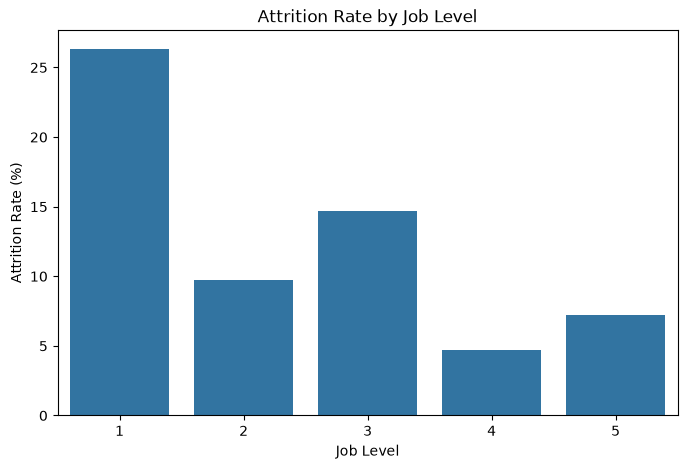

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=job_level_rate.index,
    y=job_level_rate.values
)

plt.title("Attrition Rate by Job Level")
plt.xlabel("Job Level")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [30]:
business_travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .round(2)
    .sort_values(ascending=False)
)

business_travel_rate

BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64

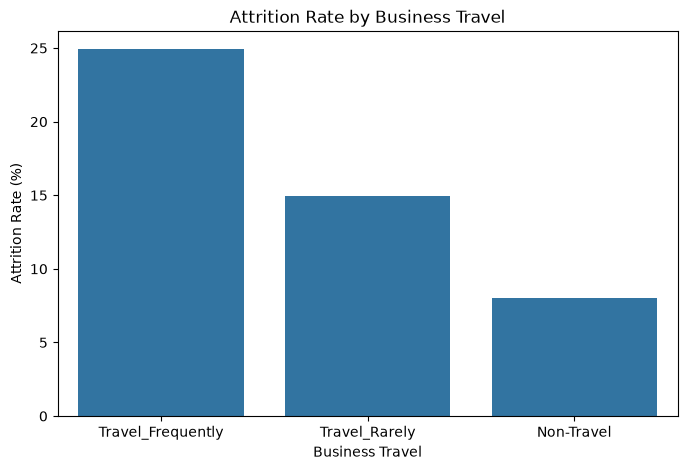

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=business_travel_rate.index,
    y=business_travel_rate.values
)

plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [32]:
distance_summary = (
    df.groupby("Attrition")["DistanceFromHome"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

distance_summary

,count,mean,median,min,max
Attrition,,,,,
No,1233,8.92,7.0,1,29
Yes,237,10.63,9.0,1,29


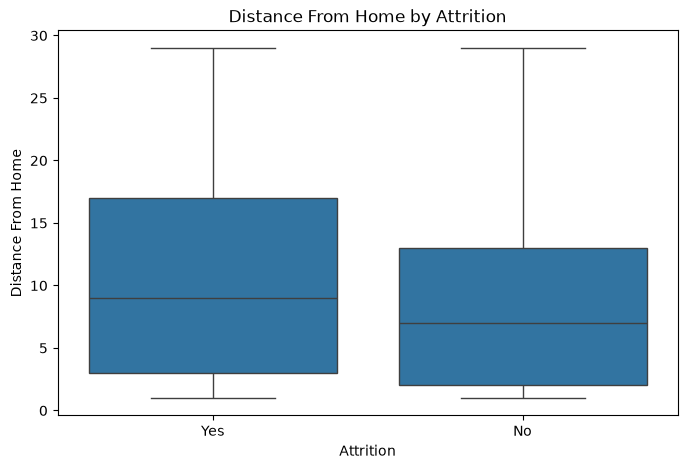

In [33]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="DistanceFromHome"
)

plt.title("Distance From Home by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")

plt.show()

In [34]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,0.01,-0.00,0.21,NaN,-0.01,0.01,0.02,0.03,0.51,...,0.05,NaN,0.04,0.68,-0.02,-0.02,0.31,0.21,0.22,0.20
DailyRate,0.01,1.00,-0.00,-0.02,NaN,-0.05,0.02,0.02,0.05,0.00,...,0.01,NaN,0.04,0.01,0.00,-0.04,-0.03,0.01,-0.03,-0.03
DistanceFromHome,-0.00,-0.00,1.00,0.02,NaN,0.03,-0.02,0.03,0.01,0.01,...,0.01,NaN,0.04,0.00,-0.04,-0.03,0.01,0.02,0.01,0.01
Education,0.21,-0.02,0.02,1.00,NaN,0.04,-0.03,0.02,0.04,0.10,...,-0.01,NaN,0.02,0.15,-0.03,0.01,0.07,0.06,0.05,0.07
EmployeeCount,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeNumber,-0.01,-0.05,0.03,0.04,NaN,1.00,0.02,0.04,-0.01,-0.02,...,-0.07,NaN,0.06,-0.01,0.02,0.01,-0.01,-0.01,-0.01,-0.01
EnvironmentSatisfaction,0.01,0.02,-0.02,-0.03,NaN,0.02,1.00,-0.05,-0.01,0.00,...,0.01,NaN,0.00,-0.00,-0.02,0.03,0.00,0.02,0.02,-0.00
HourlyRate,0.02,0.02,0.03,0.02,NaN,0.04,-0.05,1.00,0.04,-0.03,...,0.00,NaN,0.05,-0.00,-0.01,-0.00,-0.02,-0.02,-0.03,-0.02
JobInvolvement,0.03,0.05,0.01,0.04,NaN,-0.01,-0.01,0.04,1.00,-0.01,...,0.03,NaN,0.02,-0.01,-0.02,-0.01,-0.02,0.01,-0.02,0.03
JobLevel,0.51,0.00,0.01,0.10,NaN,-0.02,0.00,-0.03,-0.01,1.00,...,0.02,NaN,0.01,0.78,-0.02,0.04,0.53,0.39,0.35,0.38


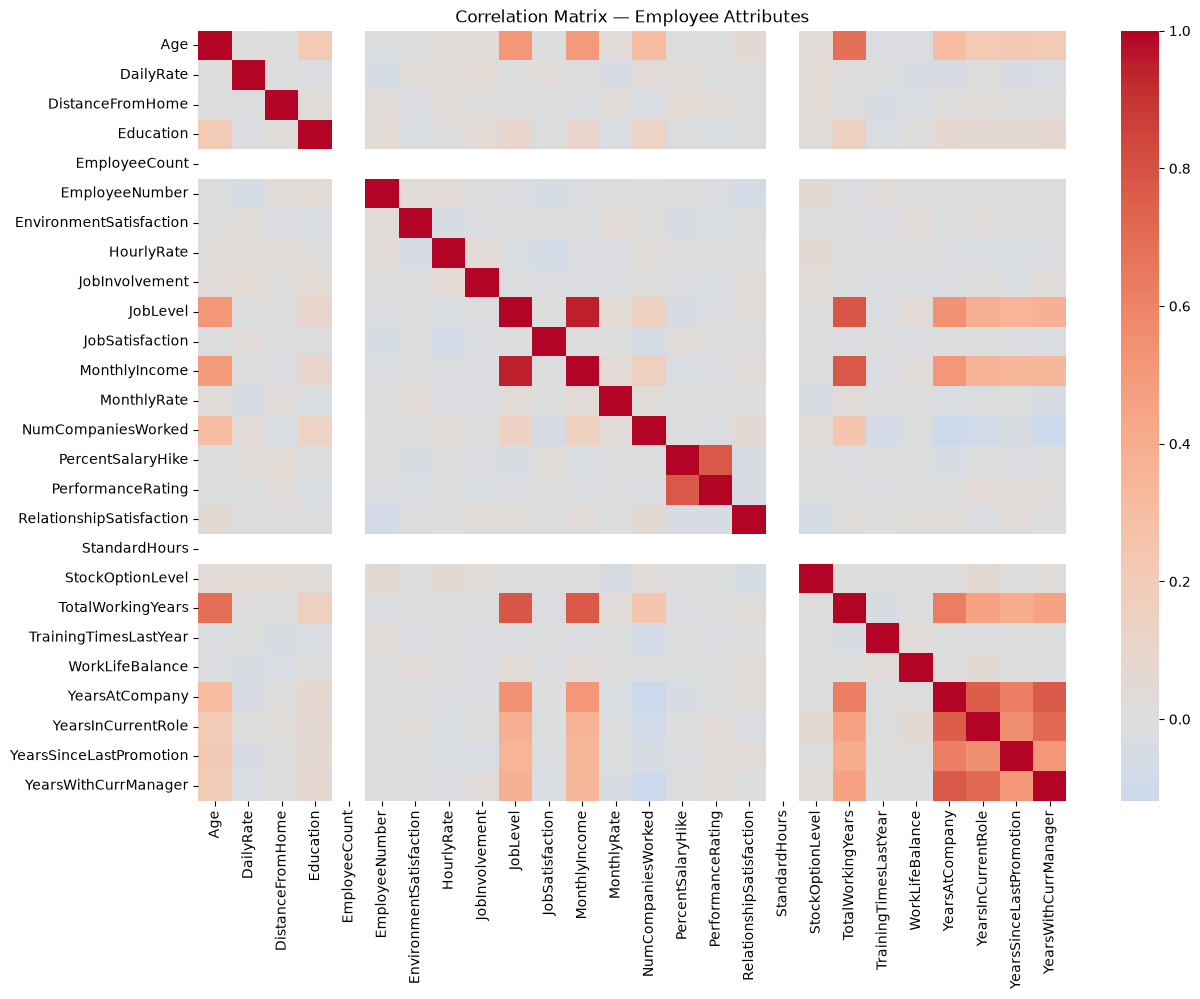

In [35]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix — Employee Attributes")
plt.show()

In [36]:
df["AttritionFlag"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

df[["Attrition", "AttritionFlag"]].head()

,Attrition,AttritionFlag
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [37]:
attrition_correlation = (
    df.select_dtypes(include="number")
    .corr()["AttritionFlag"]
    .drop("AttritionFlag")
    .sort_values()
)

attrition_correlation.round(3)

TotalWorkingYears          -0.171
JobLevel                   -0.169
YearsInCurrentRole         -0.161
MonthlyIncome              -0.160
Age                        -0.159
YearsWithCurrManager       -0.156
StockOptionLevel           -0.137
YearsAtCompany             -0.134
JobInvolvement             -0.130
JobSatisfaction            -0.103
EnvironmentSatisfaction    -0.103
WorkLifeBalance            -0.064
TrainingTimesLastYear      -0.059
DailyRate                  -0.057
RelationshipSatisfaction   -0.046
YearsSinceLastPromotion    -0.033
Education                  -0.031
PercentSalaryHike          -0.013
EmployeeNumber             -0.011
HourlyRate                 -0.007
PerformanceRating           0.003
MonthlyRate                 0.015
NumCompaniesWorked          0.043
DistanceFromHome            0.078
EmployeeCount                 NaN
StandardHours                 NaN
Name: AttritionFlag, dtype: float64

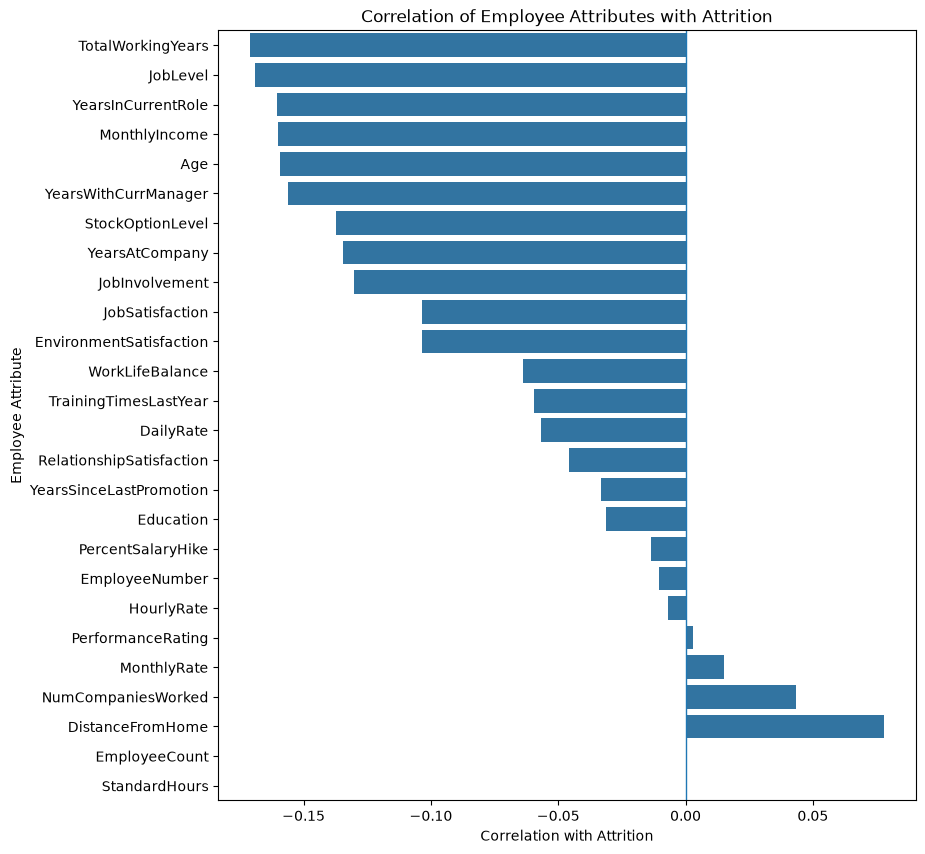

In [38]:
plt.figure(figsize=(9, 10))

sns.barplot(
    x=attrition_correlation.values,
    y=attrition_correlation.index
)

plt.title("Correlation of Employee Attributes with Attrition")
plt.xlabel("Correlation with Attrition")
plt.ylabel("Employee Attribute")

plt.axvline(0, linewidth=1)

plt.show()

In [39]:
overtime_satisfaction = pd.crosstab(
    [df["OverTime"], df["JobSatisfaction"]],
    df["Attrition"],
    normalize="index"
) * 100

overtime_satisfaction.round(2)

Attrition                    No    Yes
OverTime JobSatisfaction              
No       1                82.44  17.56
         2                90.52   9.48
         3                90.03   9.97
         4                93.06   6.94
Yes      1                64.29  35.71
         2                62.32  37.68
         3                66.12  33.88
         4                78.87  21.13

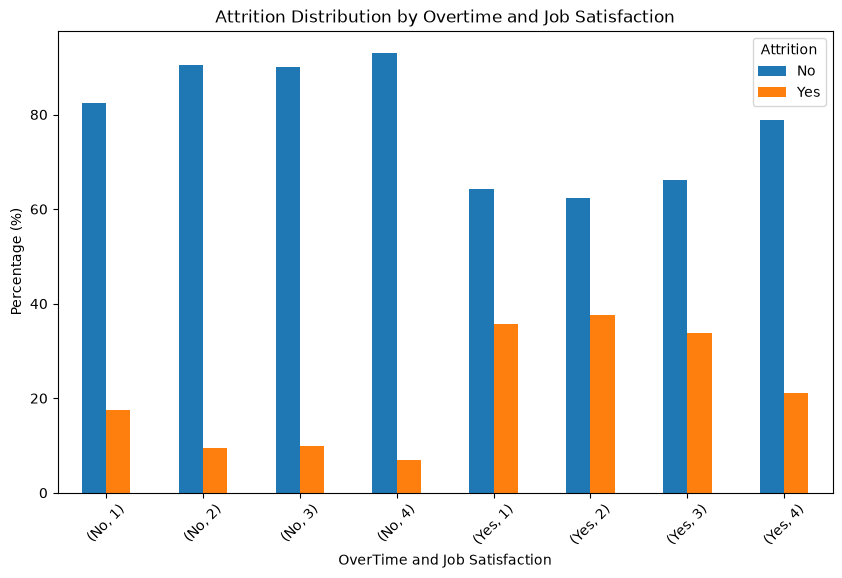

In [40]:
overtime_satisfaction.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Attrition Distribution by Overtime and Job Satisfaction")
plt.xlabel("OverTime and Job Satisfaction")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Attrition")
plt.show()